# Cafe Ocean — Exploratory Data Analysis

**Goal:** Understand transaction patterns, peak hours, top items, and revenue distribution to inform the staffing and stock purchasing models.

**Source:** `main_marts.fact_transactions` and `main_marts.dim_items` in DuckDB.


In [33]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path

DB_PATH = Path("../data/cafe_ocean.duckdb")
FIG_DIR = Path("../outputs/figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)

con = duckdb.connect(str(DB_PATH), read_only=True)

plt.rcParams.update({"figure.dpi": 120, "figure.figsize": (12, 4)})
sns.set_theme(style="whitegrid")
print("Connected to", DB_PATH)


Connected to ..\data\cafe_ocean.duckdb


## 1. Data Overview


In [34]:
overview = con.execute("""
    SELECT
        COUNT(*)                                    AS total_rows,
        COUNT(DISTINCT bill_number)                 AS unique_bills,
        COUNT(DISTINCT item_id)                     AS unique_items,
        MIN(date)                                   AS earliest_date,
        MAX(date)                                   AS latest_date,
        ROUND(SUM(total), 2)                        AS total_revenue,
        ROUND(AVG(total), 2)                        AS avg_line_item_value
    FROM main_marts.fact_transactions
""").df()
display(overview)


,total_rows,unique_bills,unique_items,earliest_date,latest_date,total_revenue,avg_line_item_value
0,145830,69982,579,2020-01-01,2020-12-31,32805895.27,224.96


145830 total transaction with 69928 bills selling 579 unique items from 2020-01-01 00:00:00 to 2020-12-31 00:00:00, making total revenue of 32805895.27 with average line item value 224.96.

In [35]:
# Data quality check
quality = con.execute("""
    SELECT
        COUNT(*) FILTER (WHERE item_id IS NULL)          AS unmatched_items,
        COUNT(*) FILTER (WHERE time_parse_failed = true) AS time_parse_failures,
        COUNT(*) FILTER (WHERE total <= 0)               AS zero_or_negative_total
    FROM main_marts.fact_transactions
""").df()
display(quality)


,unmatched_items,time_parse_failures,zero_or_negative_total
0,0,0,0


All data quality check have been passed. 

## 2. Transaction Volume Over Time


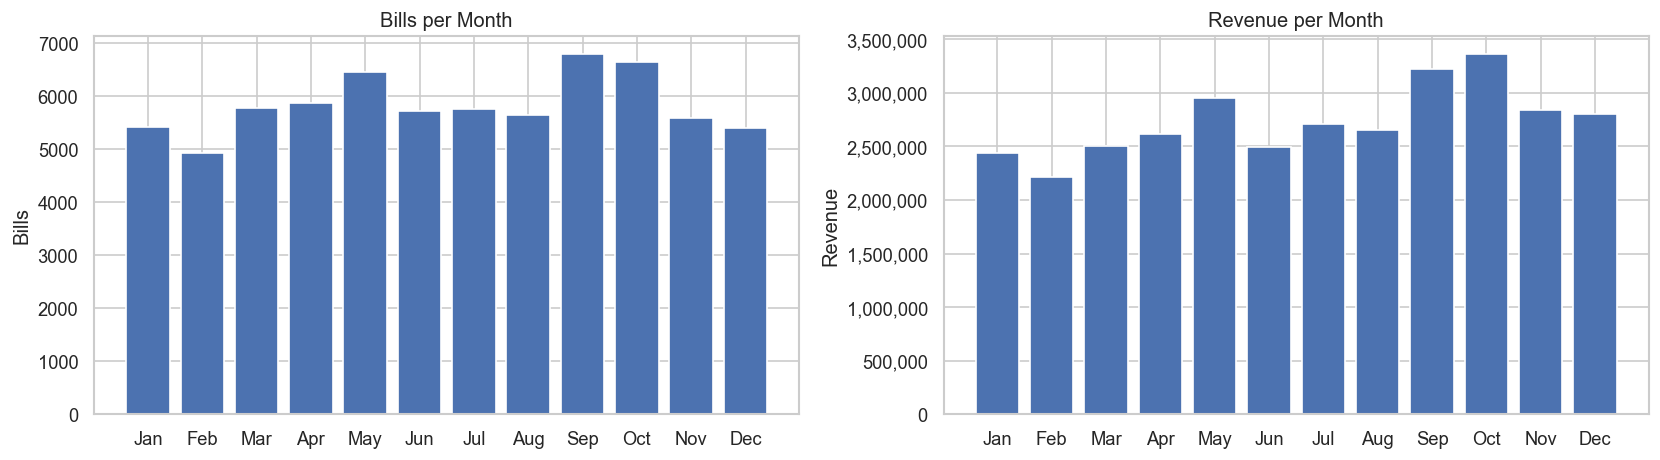

In [36]:
monthly = con.execute("""
    SELECT
        DATE_TRUNC('month', date)       AS month,
        COUNT(DISTINCT bill_number)     AS bills,
        ROUND(SUM(total), 2)            AS revenue
    FROM main_marts.fact_transactions
    GROUP BY 1 ORDER BY 1
""").df()

monthly["month_label"] = monthly["month"].dt.strftime("%b")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].bar(monthly["month_label"], monthly["bills"])
axes[0].set_title("Bills per Month"); axes[0].set_ylabel("Bills")
axes[1].bar(monthly["month_label"], monthly["revenue"])
axes[1].set_title("Revenue per Month"); axes[1].set_ylabel("Revenue")
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
plt.tight_layout()
plt.savefig(FIG_DIR / "monthly_volume.png", bbox_inches="tight")
plt.show()


Both bills per month and revenue per month peak at around September and October, and the lowest during February. It also peaks at May compared to the months before and after. 

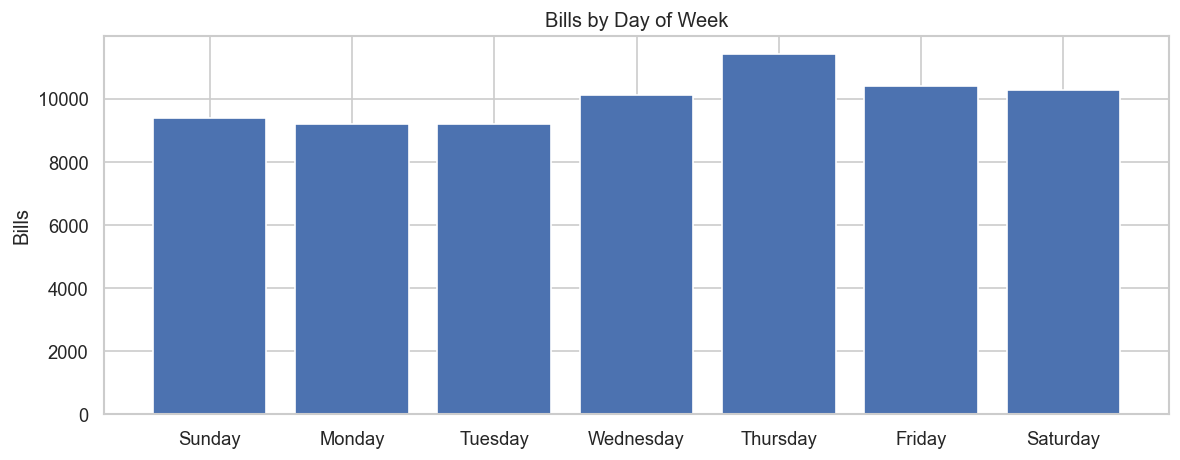

In [37]:
dow = con.execute("""
    SELECT
        DAYOFWEEK(date)             AS dow_num,
        DAYNAME(date)               AS day_name,
        COUNT(DISTINCT bill_number) AS bills
    FROM main_marts.fact_transactions
    GROUP BY 1, 2 ORDER BY 1
""").df()

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(dow["day_name"], dow["bills"])
ax.set_title("Bills by Day of Week"); ax.set_ylabel("Bills")
plt.tight_layout()
plt.savefig(FIG_DIR / "dow_volume.png", bbox_inches="tight")
plt.show()


Bills by Day of Week peaks at Thursday. 

## 3. Peak Hours Analysis

Key input for the staffing model — identifies when minimum staff requirements are highest.


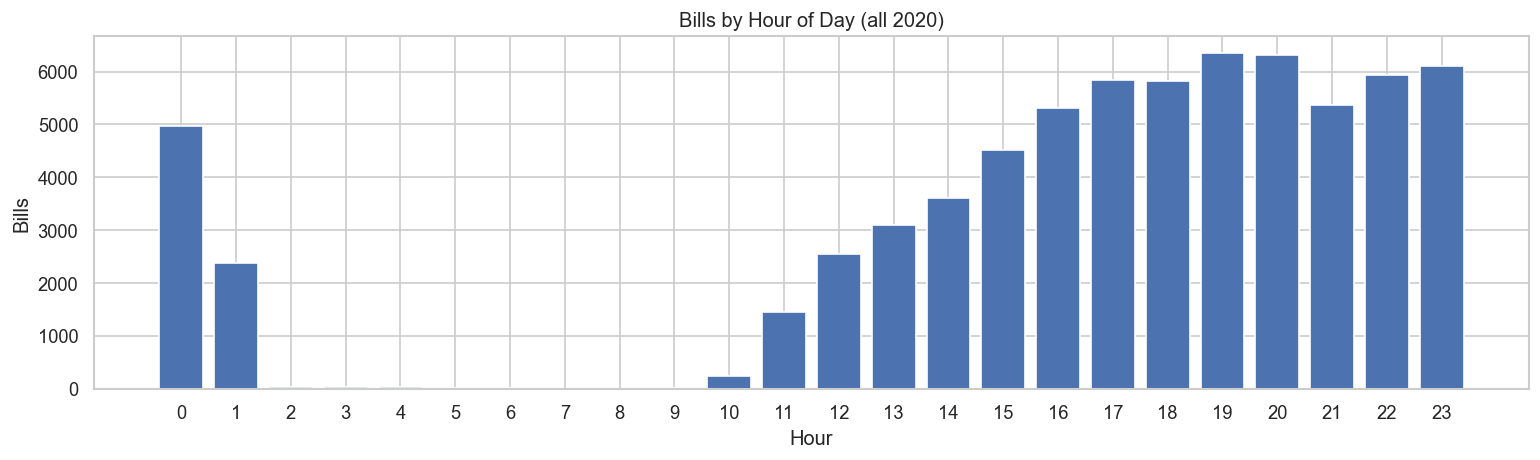

In [38]:
hourly = con.execute("""
    SELECT
        HOUR(transaction_time)          AS hour,
        COUNT(DISTINCT bill_number)     AS bills
    FROM main_marts.fact_transactions
    WHERE time_parse_failed = false
    GROUP BY 1 ORDER BY 1
""").df()

fig, ax = plt.subplots(figsize=(13, 4))
ax.bar(hourly["hour"], hourly["bills"], width=0.8)
ax.set_title("Bills by Hour of Day (all 2020)")
ax.set_xlabel("Hour"); ax.set_ylabel("Bills")
ax.set_xticks(range(0, 24))
plt.tight_layout()
plt.savefig(FIG_DIR / "peak_hours.png", bbox_inches="tight")
plt.show()


From Bills by Hour of Day (all 2020), we can see that the restaurant operates from 10 am to 1 am, while the bills peak at 19:00 to 20:59.

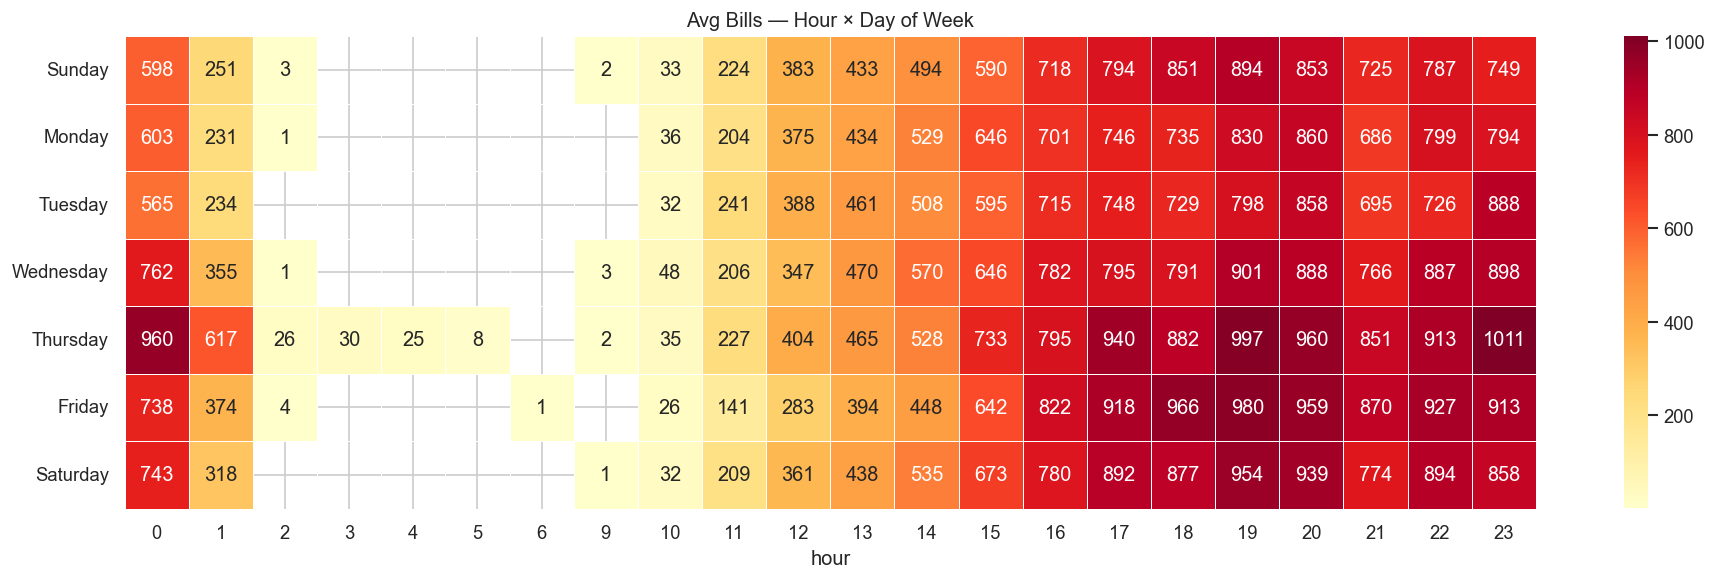

In [39]:
heatmap_data = con.execute("""
    SELECT
        DAYNAME(date)               AS day_name,
        DAYOFWEEK(date)             AS dow_num,
        HOUR(transaction_time)      AS hour,
        COUNT(DISTINCT bill_number) AS bills
    FROM main_marts.fact_transactions
    WHERE time_parse_failed = false
    GROUP BY 1, 2, 3 ORDER BY 2, 3
""").df()

pivot = heatmap_data.pivot_table(index="day_name", columns="hour", values="bills", aggfunc="mean")
day_order = ["Sunday","Monday","Tuesday","Wednesday","Thursday","Friday","Saturday"]
pivot = pivot.reindex([d for d in day_order if d in pivot.index])

fig, ax = plt.subplots(figsize=(16, 5))
sns.heatmap(pivot, ax=ax, cmap="YlOrRd", linewidths=0.5, annot=True, fmt=".0f")
ax.set_title("Avg Bills — Hour × Day of Week"); ax.set_ylabel("")
plt.tight_layout()
plt.savefig(FIG_DIR / "heatmap_hour_dow.png", bbox_inches="tight")
plt.show()


Interestingly, from the heatmap we can see that on Thursday, the store some times operate after hour (not much, only around 25 bills per hour on average). The heatmap pattern resonates with Bills by Hour of Day (all 2020) figure. 

## 4. Category & Item Breakdown


,category,transactions,units_sold,revenue,avg_line_value
0,TOBACCO,36512,37400.0,14516282.74,397.58
1,FOOD,57047,62168.0,9957702.79,174.55
2,BEVERAGE,43563,50628.0,5501861.22,126.30
3,LIQUOR,6201,10284.0,2113447.16,340.82
4,WINES,810,1075.0,353919.62,436.94
5,MISC,1156,1350.0,200046.20,173.05
6,MERCHANDISE,487,551.0,120074.02,246.56
7,LIQUOR & TPBACCO,54,63.0,42561.52,788.18


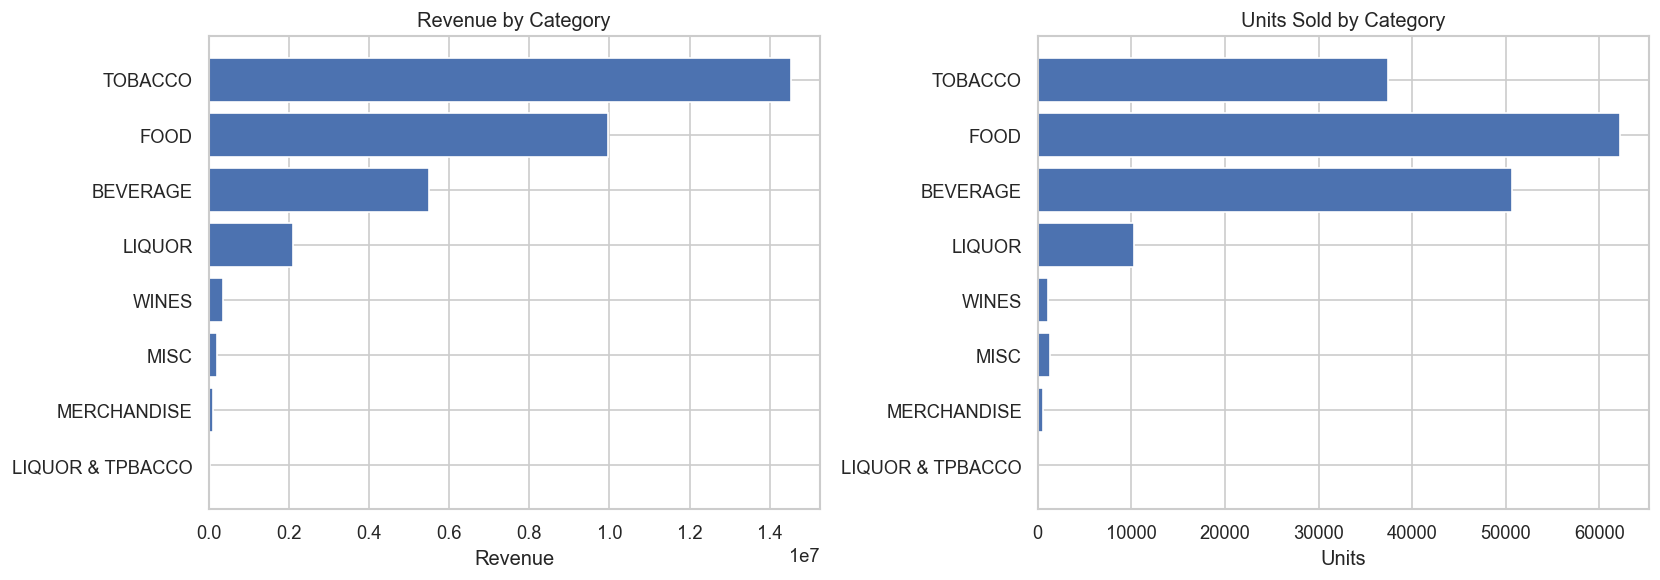

In [40]:
category = con.execute("""
    SELECT
        di.category,
        COUNT(*)                    AS transactions,
        SUM(ft.quantity)            AS units_sold,
        ROUND(SUM(ft.total), 2)     AS revenue,
        ROUND(AVG(ft.total), 2)     AS avg_line_value
    FROM main_marts.fact_transactions ft
    JOIN main_marts.dim_items di ON ft.item_id = di.item_id
    GROUP BY 1 ORDER BY revenue DESC
""").df()

display(category)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].barh(category["category"], category["revenue"]); axes[0].invert_yaxis()
axes[0].set_title("Revenue by Category"); axes[0].set_xlabel("Revenue")
axes[1].barh(category["category"], category["units_sold"]); axes[1].invert_yaxis()
axes[1].set_title("Units Sold by Category"); axes[1].set_xlabel("Units")
plt.tight_layout()
plt.savefig(FIG_DIR / "category_breakdown.png", bbox_inches="tight")
plt.show()


Tobacco generate the highest revenue followed by food, beverage, liquor, wine, and all others. Most unit sold is food, beverage, tobacco, liquor, misc, wines, and all others. 

In [41]:
top_items = con.execute("""
    SELECT
        di.item_name,
        di.category,
        SUM(ft.quantity)            AS units_sold,
        ROUND(SUM(ft.total), 2)     AS revenue
    FROM main_marts.fact_transactions ft
    JOIN main_marts.dim_items di ON ft.item_id = di.item_id
    GROUP BY 1, 2 ORDER BY revenue DESC
    LIMIT 20
""").df()
display(top_items)


,item_name,category,units_sold,revenue
0,NIRVANA HOOKAH SINGLE,TOBACCO,8686.0,2953134.60
1,SAMBUCA,TOBACCO,4765.0,2291058.00
2,MINT FLAVOUR SINGLE,TOBACCO,6019.0,1840501.00
3,CALCUTTA MINT,TOBACCO,3339.0,1640860.40
4,N R G HOOKAH,TOBACCO,2329.0,1201925.40
5,OCEAN SPECIAL SHAKE,FOOD,5914.0,843122.11
6,GREEN APPLE FLAVOUR SINGLE,TOBACCO,2590.0,793683.00
7,JR.CHL AVALANCHE,FOOD,3446.0,713565.60
8,SILVER APPLE SINGLE,TOBACCO,1985.0,673525.20
9,POUTINE WITH FRIES,FOOD,3741.0,580284.11


In [42]:
category_conflicts = con.execute("""
    SELECT
        item_desc                           AS item_name,
        COUNT(DISTINCT category)            AS category_count,
        STRING_AGG(DISTINCT category, ' / ') AS categories
    FROM main_staging.stg_transactions
    GROUP BY 1
    HAVING COUNT(DISTINCT category) > 1
    ORDER BY category_count DESC
""").df()
display(category_conflicts)

,item_name,category_count,categories
0,PHILADELPHIA CREAM CHEESECAKE,2,FOOD / MISC
1,HOTDOG WRAP,2,FOOD / MISC
2,ROMA TOMATO & JALAPENO CROQUE,2,FOOD / MISC
3,QUESO CROQUETAS FRITOS,2,MISC / FOOD
4,RED BULL 2+1,2,MISC / BEVERAGE
5,NUTELLA CREPES,2,MISC / FOOD
6,N R G HOOKAH,2,TOBACCO / BEVERAGE
7,ENG BREAKFAST TEA,2,MISC / BEVERAGE
8,ITALIAN CAPONATA PANINO,2,FOOD / MISC
9,PEACH BULL,2,BEVERAGE / MISC


## 5. Bill-level Analysis


In [43]:
bill_summary = con.execute("""
    WITH bill_agg AS (
        SELECT
            bill_number,
            COUNT(DISTINCT item_id) AS items_per_bill,
            SUM(total)              AS bill_value
        FROM main_marts.fact_transactions
        GROUP BY bill_number
    )
    SELECT
        ROUND(AVG(items_per_bill), 2)   AS avg_items_per_bill,
        ROUND(MIN(bill_value), 2)       AS min_bill_value,
        ROUND(AVG(bill_value), 2)       AS avg_bill_value,
        ROUND(MAX(bill_value), 2)       AS max_bill_value,
        COUNT(*)                        AS total_bills
    FROM bill_agg
""").df()
display(bill_summary)


,avg_items_per_bill,min_bill_value,avg_bill_value,max_bill_value,total_bills
0,2.07,1.26,468.78,14231.25,69982


Average item per bill is 2.07, minimum bill value 1.26, average bill value 468.78, max bill value 14231.25, total bills 69982.

In [44]:
# Minimum bill — what is the 1.26 transaction?
min_bill = con.execute("""
    SELECT ft.*, di.item_name
    FROM main_marts.fact_transactions ft
    JOIN main_marts.dim_items di ON ft.item_id = di.item_id
    WHERE ft.bill_number = (
        SELECT bill_number
        FROM main_marts.fact_transactions
        GROUP BY bill_number
        ORDER BY SUM(total) ASC
        LIMIT 1
    )
""").df()
display(min_bill)


,transaction_id,bill_number,date,transaction_time,time_parse_failed,item_id,quantity,rate,tax,discount,total,item_name
0,TXN063374,N0030448,2020-06-12,21:50:05,False,ITM016,1,1.0,0.26,0.0,1.26,1+1 WINE GLASS


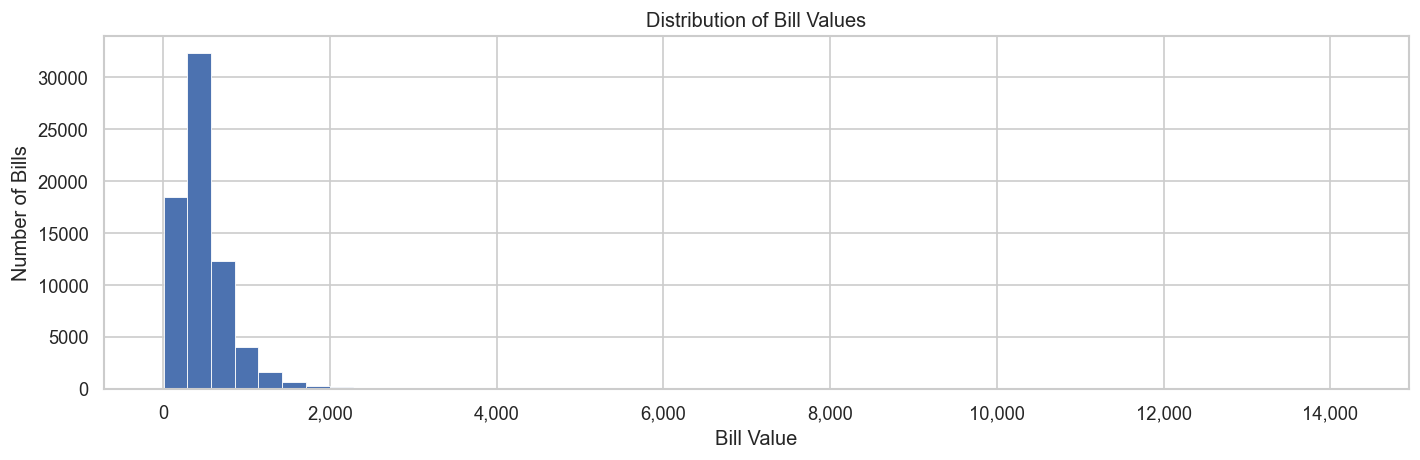

In [45]:
bill_values = con.execute("""
    SELECT bill_number, SUM(total) AS bill_value
    FROM main_marts.fact_transactions
    GROUP BY bill_number
""").df()

fig, ax = plt.subplots(figsize=(12, 4))
ax.hist(bill_values["bill_value"], bins=50, edgecolor="white", linewidth=0.5)
ax.set_title("Distribution of Bill Values")
ax.set_xlabel("Bill Value"); ax.set_ylabel("Number of Bills")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
plt.tight_layout()
plt.savefig(FIG_DIR / "bill_value_distribution.png", bbox_inches="tight")
plt.show()


The distributeion of Bill Values go up from zero, peak at round 200 (not precise), and decreases as bill value increases. 

## 6. Promotional Items (1+1)

Investigate how 1+1 items are recorded — single transaction, doubled quantity, or discounted rate — before including them in the stock model.


In [46]:
promo = con.execute("""
    SELECT
        di.item_name,
        di.category,
        COUNT(*)                    AS transactions,
        ROUND(AVG(ft.quantity), 2)  AS avg_quantity,
        ROUND(AVG(ft.rate), 2)      AS avg_rate,
        ROUND(AVG(ft.discount), 2)  AS avg_discount,
        ROUND(SUM(ft.total), 2)     AS total_revenue
    FROM main_marts.fact_transactions ft
    JOIN main_marts.dim_items di ON ft.item_id = di.item_id
    WHERE item_name LIKE '%2+1%'
       OR item_name LIKE '%3+2%'
       OR item_name LIKE '2 DOM BEER + 1SPL SHEESHA'
       OR item_name LIKE '2 DOM BEER + 1PREM SHEESHA'
       OR item_name LIKE '4 DOM BEER + 1SPL SHEESHA'
       OR item_name LIKE '2 MUFFINS + BEVERAGE'
       OR item_name LIKE '3 RED BULL'
       OR item_name LIKE '5 RED BULL'
       OR item_name LIKE '2 RED BULL'
       OR item_name LIKE 'REDBULL HOOKAH + 2REDBULL'
       OR item_name LIKE 'WAFFLES + BEVERAGE'
    GROUP BY 1, 2 ORDER BY transactions DESC
""").df()
display(promo)


,item_name,category,transactions,avg_quantity,avg_rate,avg_discount,total_revenue
0,RED BULL 2+1,BEVERAGE,1167,1.05,250.0,0.17,378941.67
1,3 RED BULL,BEVERAGE,248,1.09,300.0,0.85,100187.63
2,RED BULL 3+2,BEVERAGE,99,1.05,375.0,0.00,48262.29
3,REDBULL HOOKAH + 2REDBULL,TOBACCO,97,1.02,475.0,0.00,62073.00
4,5 RED BULL,BEVERAGE,32,1.06,450.0,0.00,18933.90
5,2 RED BULL,BEVERAGE,21,1.05,150.0,0.00,4083.85
6,TUBORG 2+1,LIQUOR,13,1.46,300.0,2.31,7471.88
7,CARLSBERG 2+1,LIQUOR,12,1.75,300.0,5.00,8250.00
8,2 DOM BEER + 1SPL SHEESHA,LIQUOR & TPBACCO,10,1.00,500.0,0.00,6562.50
9,STELLA 1LTR 2+1,LIQUOR,4,1.25,1300.0,0.00,8531.25


In [47]:
# Other promotion naming patterns
other_promos = con.execute("""
    SELECT DISTINCT item_name, category
    FROM main_marts.dim_items
    WHERE item_name LIKE '%2+1%'
       OR item_name LIKE '%3+2%'
       OR item_name LIKE '2 DOM BEER + 1SPL SHEESHA'
       OR item_name LIKE '2 DOM BEER + 1PREM SHEESHA'
       OR item_name LIKE '4 DOM BEER + 1SPL SHEESHA'
       OR item_name LIKE '2 MUFFINS + BEVERAGE'
       OR item_name LIKE '3 RED BULL'
       OR item_name LIKE '5 RED BULL'
       OR item_name LIKE '2 RED BULL'
       OR item_name LIKE 'REDBULL HOOKAH + 2REDBULL'
       OR item_name LIKE 'WAFFLES + BEVERAGE'
    ORDER BY item_name
""").df()
display(other_promos)


,item_name,category
0,2 DOM BEER + 1PREM SHEESHA,LIQUOR & TPBACCO
1,2 DOM BEER + 1SPL SHEESHA,LIQUOR & TPBACCO
2,2 MUFFINS + BEVERAGE,FOOD
3,2 RED BULL,BEVERAGE
4,3 RED BULL,BEVERAGE
5,4 DOM BEER + 1SPL SHEESHA,LIQUOR & TPBACCO
6,5 RED BULL,BEVERAGE
7,CARLSBERG 2+1,LIQUOR
8,HOEGAARDEN GLS (2+1),MISC
9,HOEGAARDEN LTR MUGS (2+1),MISC


In [48]:
# Check promo flags landed correctly
con.execute("""
    SELECT item_name, category, promotion_type, stock_multiplier
    FROM main_marts.dim_items
    WHERE promotion_type IS NOT NULL
    ORDER BY promotion_type, item_name
""").df()

,item_name,category,promotion_type,stock_multiplier
0,1+1 BTL4 SEASON WHITE,WINES,1+1,2
1,1+1 GLS 4SEASON RED,WINES,1+1,2
2,1+1 GLS 4SEASONS WHITE,WINES,1+1,2
3,1+1 KF 1 LITER,LIQUOR,1+1,2
4,1+1 KF 1/2 LITER,LIQUOR,1+1,2
5,1+1 KF 2 LITER,LIQUOR,1+1,2
6,1+1 VLN CAB SAUV (BTL),WINES,1+1,2
7,1+1 VLN CAB SAUV (GLS),WINES,1+1,2
8,1+1 VLN CAB SAUV CLASIQ (BTL),WINES,1+1,2
9,1+1 VLN CAB SAUV CLASIQ (GLS),WINES,1+1,2


In [49]:
con.close()
print("Done. Figures saved to", FIG_DIR)


Done. Figures saved to ..\outputs\figures
